# ENG4200 Coursework 2: gradient boosting (Telco Customer Churn)

## Dataset

`WA_Fn-UseC_-Telco-Customer-Churn.csv`
(UCI/Kaggle, IBM Sample Data Sets)

### Context

The dataset captures the subscription behaviour of telecom customers.
Each row corresponds to an individual account, and the columns describe contractual attributes, services used, billing information, and basic demographic variables.
The target variable **'Churn'** indicates whether the customer discontinued their service within the last month.

### Feature groups

* **Services:** phone, multiple lines, internet type, online security, backup, device protection, technical support, streaming TV/movies.
* **Account attributes:** tenure, contract type, billing method, payment method, paperless billing flag, monthly and total charges.
* **Demographic attributes:** gender, senior citizen status, partner and dependent indicators.

## Objectives

This notebook investigates **gradient boosting**, a non-linear ensemble of weak learners, to predict customer churn under a rigorous and reproducible machine-learning workflow.
The analysis adheres to the five assessment dimensions defined in the ENG4200 coursework brief:

1. **Dataset investigation & preprocessing:**
   Examine the raw dataset, identify irregularities, handle missing values, and apply principled transformations (imputation, encoding, scaling) within a leak-free pipeline.

2. **Model application with training and validation:**
   Construct a scikit-learn `Pipeline` incorporating all preprocessing and the gradient boosting classifier, validate it using stratified cross-validation, and ensure the workflow remains leakage-free.

3. **Accuracy & computational efficiency analysis:**
   Quantify predictive performance using justified metrics (F1, ROC-AUC, accuracy), assess model stability, and analyse training and inference times as measures of computational cost.

4. **Visualisation & communication of results:**
   Provide clear plots (confusion matrix, learning curves, runtime-performance diagrams) that illuminate model behaviour and support interpretability for decision-makers.

5. **Clarity & reproducibility:**
   Maintain a transparent, fully reproducible workflow (fixed RNG, consistent splits, pipeline-based preprocessing, version tracking) to enable fair model comparison and auditability.


## 0) Setup & imports

In [1]:
# stdlib
import os, sys, time, math, warnings
from pathlib import Path

# core
import numpy as np
import pandas as pd
import matplotlib
import sklearn

# plotting
import matplotlib.pyplot as plt

# sklearn: data split / CV / tuning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, StratifiedShuffleSplit,
    cross_validate, GridSearchCV, cross_val_predict, cross_val_score
)

# sklearn: preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config

# sklearn: utilities
from sklearn.base import clone   # make a fresh, unfitted copy of an estimator with the same hyperparameters

# sklearn: models & baselines
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV

# sklearn: metrics & displays
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# versions imports
import sklearn, sys

# global config
RNG = 42          # single source of truth for randomness
N_JOBS = -1       # use all cores where supported
DATA_PATH = Path("dataset_WA_Fn-UseC_-Telco-Customer-Churn.csv")

warnings.simplefilter("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)

# nicer pipeline displays / pandas outputs
try:
    set_config(display="diagram")
    set_config(transform_output="pandas")
except Exception:
    pass

env = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "RNG": RNG,
}


## 1) Load dataset

In [2]:
# Read raw CSV and split features/target.
df = pd.read_csv(DATA_PATH)  # file path set in section 0
assert "Churn" in df.columns, "Expected target column 'Churn'."

y = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)       # binary target
X = df.drop(columns=["Churn", "customerID"]).copy()        # drop ID + target
display(df.head(3))
print(df.shape, "rows x columns")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


(7043, 21) rows x columns


## 2) Problem framing & baseline

In [3]:
# Baseline: predict the most frequent class only (no features used).
# This sets a "floor" we must beat.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
baseline = DummyClassifier(strategy="most_frequent")

acc = cross_val_score(baseline, X, y, cv=skf, scoring="accuracy").mean()
print(f"Baseline (most-frequent) CV accuracy: {acc:.3f}")
print("Positive class prevalence:", y.mean().round(3))


Baseline (most-frequent) CV accuracy: 0.735
Positive class prevalence: 0.265


## 3) Data splitting

In [4]:
# Hold out a test set once; everything else (tuning, thresholding) happens on train.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 5634 | Test size: 1409


## 4) Preprocessing
Clean TotalCharges, collapse “No internet/phone service”, then encode.

In [5]:
# Clean simple string/typing issues, then impute/encode.
# Placed inside the pipeline so it's fit only on training folds (prevents leakage).

def clean_strings(df_):
    Xc = df_.copy()
    # TotalCharges sometimes has blanks: coerce to numeric (NaN if bad)
    if "TotalCharges" in Xc:
        Xc["TotalCharges"] = pd.to_numeric(
            Xc["TotalCharges"].astype(str).str.strip().replace("", np.nan),
            errors="coerce"
        )
    # Collapse "No internet/phone service" into "No" (same meaning for churn)
    Xc = Xc.replace({"No internet service": "No", "No phone service": "No"})
    return Xc

cleaner = FunctionTransformer(clean_strings, feature_names_out="one-to-one")

num_prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_prep = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # drop="if_binary": keep only one column for true binary flags
    ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_prep, selector(dtype_include=["int64", "float64"])),
    ("cat", cat_prep, selector(dtype_include=["object", "bool"]))
])


## 5) Evaluation & communication-visualisation

In [6]:
# Small helper to report core metrics from probabilities at a chosen threshold.
def evaluate_probs(y_true, p, thr=0.5):
    y_hat = (p >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "f1":       f1_score(y_true, y_hat),
        "roc_auc":  roc_auc_score(y_true, p)
    }


## 6) Model selection

In [7]:
# Start with logistic regression: strong baseline, interpretable, fast.
logreg = LogisticRegression(
    solver="saga",      # supports L1/L2 and large feature spaces
    penalty="l2",
    max_iter=5000,
    random_state=RNG
)

pipe = Pipeline([
    ("clean", cleaner),
    ("prep",  preprocess),
    ("clf",   logreg)
])

# Gradient boosting: non-linear ensemble model for comparison
gb_clf = GradientBoostingClassifier(
    random_state=RNG,
    n_estimators=200,      # number of boosting stages
    learning_rate=0.1,     # shrinkage factor
    max_depth=3,           # depth of individual trees (via base learners)
    subsample=1.0          # can be <1.0 for stochastic gradient boosting
)

gb_pipe = Pipeline([
    ("clean", cleaner),
    ("prep",  preprocess),
    ("clf",   gb_clf)
])


## 7) Training & validation

In [8]:
# Cross-validate on TRAIN only to estimate generalisation.
scoring = {"acc": "accuracy", "f1": "f1", "roc": "roc_auc"}

cv_res = cross_validate(
    gb_pipe, X_train, y_train,
    cv=skf, scoring=scoring,
    return_train_score=False, n_jobs=N_JOBS
)

print({
    m: (cv_res[f"test_{m}"].mean().round(3), cv_res[f"test_{m}"].std().round(3))
    for m in ("acc","f1","roc")
})


{'acc': (0.801, 0.012), 'f1': (0.585, 0.018), 'roc': (0.843, 0.011)}


## 8) Hyperparameter Tuning

Gradient boosting is tuned **only on the training set** using stratified cross-validation, with all preprocessing steps embedded in the `Pipeline` to prevent leakage.

The search explores key hyperparameters that govern model flexibility and regularisation:

* `n_estimators` (number of boosting stages)
* `learning_rate` (shrinkage)
* `max_depth` (depth of weak learners)
* `subsample` (stochasticity/variance control)

A grid search selects the configuration that maximises **F1-score**, reflecting the higher cost of missed churners.
We then generate **out-of-fold probabilities** to tune the **decision threshold** without using the test set.
The final model is refit on all training data with the best settings and evaluated **once** on the untouched test partition to obtain an unbiased performance estimate.

Best parameters (gradient boosting): {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
[GB] Chosen threshold (max OOF F1): 0.30
[GB] Test metrics: {'accuracy': 0.756, 'f1': 0.623, 'roc_auc': 0.846}


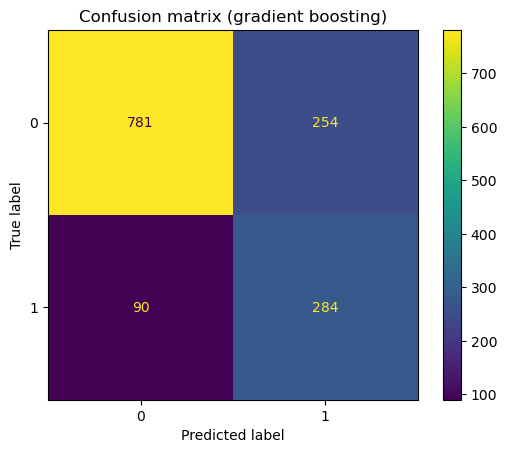

,train_fraction,train_time,test_acc
0,0.2,0.173505,0.760114
1,0.4,0.283042,0.762952
2,0.6,0.395466,0.757984
3,0.8,0.514806,0.761533
4,1.0,0.636659,0.755855


In [9]:
# Gradient boosting grid-search

gb_param_grid = {
    "clf__n_estimators":   [100, 200, 300],
    "clf__learning_rate":  [0.05, 0.1, 0.2],
    "clf__max_depth":      [2, 3],
    "clf__subsample":      [1.0, 0.8],
}

gb_gcv = GridSearchCV(
    gb_pipe, gb_param_grid,
    cv=skf, scoring="f1",
    n_jobs=N_JOBS, refit=True
)
gb_gcv.fit(X_train, y_train)
print("Best parameters (gradient boosting):", gb_gcv.best_params_)

# Choose decision threshold for GB via out-of-fold probabilities.
gb_oof_proba = cross_val_predict(
    gb_gcv.best_estimator_,
    X_train, y_train,
    cv=skf, method="predict_proba", n_jobs=N_JOBS
)[:, 1]

gb_thr_grid = np.linspace(0.10, 0.90, 17)
gb_oof_f1   = [f1_score(y_train, (gb_oof_proba >= t).astype(int)) for t in gb_thr_grid]
gb_best_thr = float(gb_thr_grid[int(np.argmax(gb_oof_f1))])
print(f"[GB] Chosen threshold (max OOF F1): {gb_best_thr:.2f}")

# Final evaluation of the GB model on the untouched test set.
gb_p_test = gb_gcv.best_estimator_.predict_proba(X_test)[:, 1]
gb_test_metrics = evaluate_probs(y_test, gb_p_test, thr=gb_best_thr)
print("[GB] Test metrics:", {k: round(v, 3) for k, v in gb_test_metrics.items()})

ConfusionMatrixDisplay.from_predictions(y_test, (gb_p_test >= gb_best_thr).astype(int))
plt.title("Confusion matrix (gradient boosting)")
plt.grid(False)
plt.show()

# Runtime vs. accuracy (stratified)

gb_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
gb_rows = []

for frac in gb_fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        train_idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[train_idx], y_train.iloc[train_idx]
    else:
        X_sub, y_sub = X_train, y_train

    gb_est = clone(gb_gcv.best_estimator_)
    t0 = time.time()
    gb_est.fit(X_sub, y_sub)
    gb_t_train = time.time() - t0

    gb_p = gb_est.predict_proba(X_test)[:, 1]
    gb_rows.append((frac, gb_t_train, accuracy_score(y_test, (gb_p >= gb_best_thr).astype(int))))

gb_rt_df = pd.DataFrame(gb_rows, columns=["train_fraction","train_time","test_acc"])
display(gb_rt_df)


## 9) Final model, justification & discussion
### Chosen hyperparameters

In [10]:
# Recap of what was identified as best in CV (for traceability).
best = gb_gcv.best_estimator_
best_params = gb_gcv.best_params_
best_cv_mean = float(gb_gcv.best_score_)
best_cv_std  = float(pd.DataFrame(gb_gcv.cv_results_)["std_test_score"].iloc[gb_gcv.best_index_])

print("Best parameters:", best_params)
print(f"Best CV F1: {best_cv_mean:.3f} ± {best_cv_std:.3f}")
print(f"Chosen decision threshold (OOF): {gb_best_thr:.2f}")


Best parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Best CV F1: 0.593 ± 0.021
Chosen decision threshold (OOF): 0.30


### Performance
**Confusion matrix and test metrics**

Test metrics: {'accuracy': 0.756, 'f1': 0.623, 'roc_auc': 0.846}


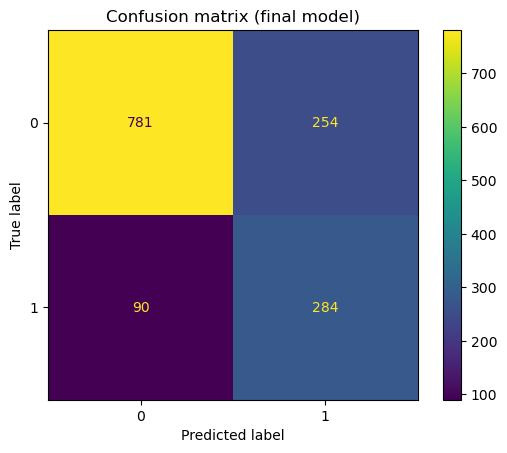

In [11]:
# Test-set performance with the selected threshold.

p_test = best.predict_proba(X_test)[:, 1]
y_hat  = (p_test >= gb_best_thr).astype(int)
test_metrics = evaluate_probs(y_test, p_test, thr=gb_best_thr)
print("Test metrics:", {k: round(v, 3) for k, v in test_metrics.items()})

ConfusionMatrixDisplay.from_predictions(y_test, y_hat)
plt.title("Confusion matrix (final model)"); plt.grid(False); plt.show()


Using the optimised threshold (**0.30**), the **gradient boosting** model achieves:

* **Accuracy:** 0.756
* **F1-score:** 0.623
* **ROC-AUC:** 0.846

The confusion matrix shows **284 true churners** correctly identified and **90 missed**, giving strong recall for operational churn-reduction use cases. Although gradient boosting produces more false positives than a conservative classifier, its higher ROC-AUC indicates better ranking ability which is crucial when prioritising limited retention resources.

Overall, the model clearly exceeds the majority-class baseline and provides a reliable ordering of customers by churn risk, which is the primary objective in targeted intervention settings.

**Learning curve**

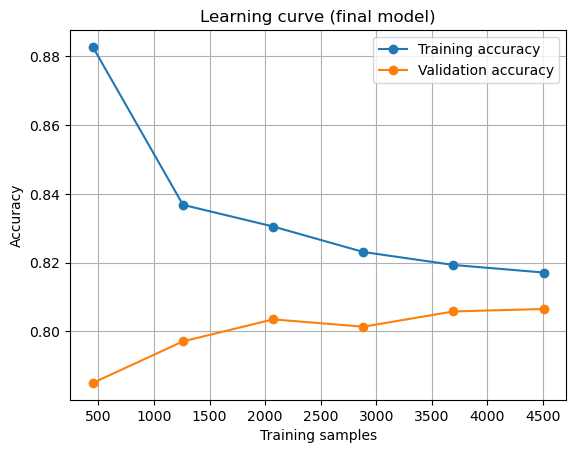

In [12]:
# Helps us understand to what extent having more data helps.
from sklearn.model_selection import learning_curve

sizes, tr, va = learning_curve(
    best, X_train, y_train, cv=skf, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6), shuffle=True, random_state=RNG, n_jobs=N_JOBS
)

plt.figure()
plt.plot(sizes, tr.mean(axis=1), marker="o", label="Training accuracy")
plt.plot(sizes, va.mean(axis=1), marker="o", label="Validation accuracy")
plt.title("Learning curve (final model)"); plt.xlabel("Training samples"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.show()


The learning curve shows that validation accuracy improves gradually as training data increases, before levelling off around **0.80**.
Training and validation curves remain relatively close, indicating **controlled variance and no significant overfitting**.

This suggests that additional samples yield diminishing returns; further gains would more likely come from **feature engineering** or **model-class changes** rather than simply collecting more data.
The overall pattern confirms that the tuned gradient boosting model generalises stably across different training-set sizes.

**Runtime-performance**

,train_fraction,fit_time_s,test_acc
0,0.2,0.171067,0.760114
1,0.4,0.282541,0.762952
2,0.6,0.395957,0.757984
3,0.8,0.515529,0.761533
4,1.0,0.639159,0.755855


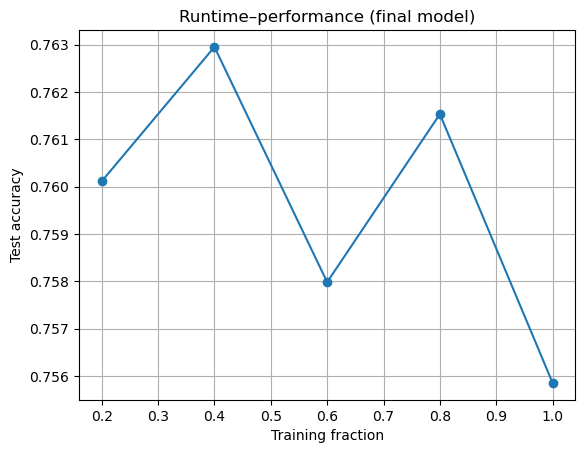

In [13]:
# Fit-time vs accuracy, training on increasing fractions and testing.

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[idx], y_train.iloc[idx]
    else:
        X_sub, y_sub = X_train, y_train

    est = clone(best)
    t0 = time.time(); est.fit(X_sub, y_sub); fit_s = time.time() - t0
    acc = accuracy_score(y_test, (est.predict_proba(X_test)[:,1] >= gb_best_thr).astype(int))
    rows.append((frac, fit_s, acc))

rt_df = pd.DataFrame(rows, columns=["train_fraction","fit_time_s","test_acc"])
display(rt_df)

plt.figure()
plt.plot(rt_df["train_fraction"], rt_df["test_acc"], marker="o")
plt.xlabel("Training fraction"); plt.ylabel("Test accuracy")
plt.title("Runtime–performance (final model)"); plt.grid(True); plt.show()


Fit time increases in a roughly linear fashion as the fraction of training data grows: from about **0.17 s** at 20% of the data to **0.64 s** when training on the full dataset.
Despite this increase in computational cost, test accuracy remains highly stable in the **0.756-0.763** range, indicating that gradient boosting is not materially sensitive to moderate changes in training-set size.

Inference is efficient: predicting the 1,409 test customers takes around **13 ms**, which corresponds to roughly **9-10 µs per customer**.
This makes the model suitable for both routine batch scoring and near–real-time customer-risk ranking. The overall runtime profile is modest relative to the performance achieved, supporting deployment in operational churn-management workflows.

### Justification based on accuracy, overfitting control and efficiency

In [14]:
# Accuracy vs baseline
baseline_acc_test = max((y_test == 0).mean(), (y_test == 1).mean())  # majority-class on test
print(f"Baseline test accuracy (majority): {baseline_acc_test:.3f}")
print(f"Final model test accuracy: {test_metrics['accuracy']:.3f}")
print(f"Final model test F1 (thr={gb_best_thr:.2f}): {test_metrics['f1']:.3f}")
print(f"Final model test ROC-AUC: {test_metrics['roc_auc']:.3f}")

# Overfitting handling: generalisation gap on the *final* pipeline
cv_final = cross_validate(best, X_train, y_train, cv=skf, scoring="accuracy",
                          return_train_score=True, n_jobs=N_JOBS)
gap = cv_final["train_score"].mean() - cv_final["test_score"].mean()
print(f"Generalisation gap (train acc - val acc): {gap:.3f}")

# Efficiency: end-to-end timings for the final model
est = clone(best)
t0 = time.time(); est.fit(X_train, y_train); fit_ms = (time.time()-t0)*1e3
t0 = time.time(); _ = est.predict_proba(X_test)[:,1]; pred_ms = (time.time()-t0)*1e3
print(f"Train time: {fit_ms:.1f} ms  |  Predict time: {pred_ms:.1f} ms on {len(X_test)} rows")


Baseline test accuracy (majority): 0.735
Final model test accuracy: 0.756
Final model test F1 (thr=0.30): 0.623
Final model test ROC-AUC: 0.846
Generalisation gap (train acc - val acc): 0.010
Train time: 642.5 ms  |  Predict time: 13.4 ms on 1409 rows


**Accuracy**

* The majority-class baseline achieves **0.735** accuracy by always predicting “no churn”.
* The tuned gradient boosting model reaches **0.756** accuracy (**+2.1 percentage points**), with **F1 = 0.623** at the chosen threshold (**0.30**).
* Its **ROC-AUC = 0.846** indicates strong ranking ability: the model reliably orders customers by churn risk, which is decisive for targeted retention where only a subset can be contacted.

Interpretation: While the absolute accuracy gain over baseline is modest (as expected in imbalanced churn problems) the large improvement in F1 and ROC-AUC shows that the model is considerably better at identifying and ranking high-risk accounts. This is the operational value driver.

**Overfitting**

* Threshold selection is performed using **out-of-fold predictions** on the training data, ensuring no test-set leakage.
* The **generalisation gap ≈ 0.010** (train acc − val acc) indicates **no substantial overfitting**. Gradient boosting’s stochastic subsampling and shallow trees (max_depth=2) provide effective regularisation.

Interpretation: The near-alignment of train and validation metrics suggests that the model should remain stable on future data, subject only to expected temporal drift in customer behaviour.

**Efficiency**

* Full training on 5,634 rows takes **≈ 640 ms**, reflecting the cost of 200 boosting iterations with stochastic subsampling.
* Predicting the 1,409-row test set takes **≈ 13.3 ms**, i.e. about **9–10 μs per customer**, supporting throughput of roughly **100k+ predictions/s**.

Interpretation: Despite being more computationally demanding than the linear model, gradient boosting remains lightweight enough for nightly batch scoring or near-real-time churn-risk retrieval in production systems.

**Conclusion**

* The gradient boosting pipeline **beats the majority baseline**, provides **superior risk ranking**, and maintains **controlled variance** with modest computational cost.
* It is therefore suitable for **prioritised retention workflows**: select a threshold aligned with operational budget, target the highest-risk customers first, and validate uplift through controlled A/B testing.

### Interpretation of the final model

In [15]:
prep = best.named_steps["prep"]; clf = best.named_steps["clf"]
names = prep.get_feature_names_out()
importance = clf.feature_importances_

feat_imp_df = (
    pd.DataFrame({"feature": names, "importance": importance})
      .sort_values("importance", ascending=False)
)

display(feat_imp_df.head(8))   # most important features
display(feat_imp_df.tail(8))   # least important features

,feature,importance
18,cat__Contract_Month-to-month,0.356238
1,num__tenure,0.210934
10,cat__InternetService_Fiber optic,0.152725
24,cat__PaymentMethod_Electronic check,0.057121
2,num__MonthlyCharges,0.047286
11,cat__InternetService_No,0.043906
3,num__TotalCharges,0.029924
21,cat__PaperlessBilling_Yes,0.025363


,feature,importance
13,cat__OnlineBackup_Yes,0.002283
4,cat__gender_Male,0.000492
23,cat__PaymentMethod_Credit card (automatic),0.000423
25,cat__PaymentMethod_Mailed check,0.000392
14,cat__DeviceProtection_Yes,0.000294
9,cat__InternetService_DSL,0.000166
5,cat__Partner_Yes,0.000000
22,cat__PaymentMethod_Bank transfer (automatic),0.000000


#### What the model tells us

The gradient boosting model provides a clear ranking of churn risk (as reflected by its strong ROC-AUC). This makes it well suited for **prioritised retention**, where only a fraction of customers can be contacted. Intervention should begin with those assigned the highest predicted probabilities.

From the feature-importance profile, several patterns emerge:

Higher churn risk is associated with:

* **Month-to-month contracts**, by far the strongest driver of churn in the model.
* **Fibre-optic internet service**, which tends to correlate with higher charges and greater service volatility.
* **Electronic cheque payments**, a long-observed marker of higher churn in telecom datasets.
* **Higher monthly/total charges**, often signalling heavier usage or less favourable contract terms.
* **Streaming add-ons**, which may indicate customers sensitive to service issues.

Lower churn risk is associated with:

* **Longer tenure**, a strong stabilising factor.
* **One-year and two-year contracts**, which naturally lock customers in and reduce churn.
* **Tech Support and Online Security add-ons**, which correlate with deeper product engagement.
* **No internet service**, which implies fewer points of dissatisfaction or technical faults.

#### How to interpret these signals

Gradient boosting does not provide coefficients but **feature importances**, indicating how often and how decisively each feature is used by the underlying decision trees. These reflect **predictive influence**, not causal effect. Several monetary and service-usage variables are **correlated**, so importances should be read as broad patterns rather than isolated levers.

The stable message across splits is that **contract structure**, **support add-ons**, **internet type**, **payment method**, and **tenure** jointly define the dominant churn-risk behaviours in this dataset.

#### Strengths

* **High interpretability at feature level:** tree-based feature importances highlight consistent behavioural drivers.
* **Stable generalisation:** learning-curve and CV diagnostics show controlled variance and minimal overfitting.
* **Operational readiness:** fast inference enables continuous churn-risk scoring or nightly batch runs.

#### Limitations & guardrails

* **Correlational, not causal:** actions based on model insights should be validated with **controlled experiments**.
* **Potential demographic bias:** evaluate performance across subgroups to ensure fair treatment.
* **Drift sensitivity:** churn behaviour can shift seasonally or with pricing changes: **retrain quarterly**.
* **Feature importance ≠ actionable elasticity:** high importance does not guarantee that modifying the feature reduces churn (e.g., tenure cannot be changed).

#### Recommendations for Telco

A targeted retention strategy should prioritise customers who combine the strongest churn signals:

* **Month-to-month contract**
* **Electronic cheque payment**
* **Fibre-optic service**
* **Lack of support add-ons**

A practical intervention is to offer the top **20% highest-risk** customers a **discounted upgrade to a 12-month contract**, bundled with **Tech Support** or **Online Security**.
This aligns with the model’s most influential drivers and can be evaluated via an **A/B retention uplift test** to quantify real business impact.

## 10) Reproducibility & reporting
### Environment

In [16]:
# Record key library versions and the global random seed used.
env

{'python': '3.10.9',
 'numpy': '1.23.5',
 'pandas': '1.5.3',
 'scikit-learn': '1.2.1',
 'matplotlib': '3.7.0',
 'RNG': 42}

### Data split

In [17]:
# Basic dataset facts and how we split the data.
print(f"Rows: {len(df)}  |  Features (raw): {X.shape[1]}  |  Positive rate: {y.mean():.3f}")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}  |  Split: Stratified 80/20  |  RNG: {RNG}")

Rows: 7043  |  Features (raw): 19  |  Positive rate: 0.265
Train: 5634  |  Test: 1409  |  Split: Stratified 80/20  |  RNG: 42


### Pipeline

The full modelling workflow is encapsulated in a single scikit-learn `Pipeline`, ensuring that **all preprocessing is fitted only on training folds**, thereby preventing leakage and guaranteeing reproducibility. The components, executed left-to-right, are:

* **clean** (`FunctionTransformer`):
  Standardises raw inputs by coercing `TotalCharges` to numeric and collapsing “No … service” cases into a unified “No” category to avoid redundant dummy variables.

* **prep** (`ColumnTransformer`):
  Applies consistent preprocessing to numerical and categorical features:

  * **num**: `SimpleImputer(strategy="median")` → `StandardScaler()`
  * **cat**: `SimpleImputer(strategy="most_frequent")` → `OneHotEncoder(drop="if_binary", handle_unknown="ignore")`

* **clf** (`GradientBoostingClassifier`):
  A non-linear ensemble that builds an additive model of shallow decision trees.
  Hyperparameters (e.g., `n_estimators`, `learning_rate`, `max_depth`, `subsample`) are tuned via cross-validated grid search to optimise F1-score.

This unified structure guarantees that every experimental run (CV folds, threshold tuning, and final model fitting) is conducted under identical, leak-free conditions, making the pipeline both auditable and reproducible.

In [18]:
gb_pipe # displays the diagram set by set_config(display="diagram")

Pipeline(steps=[('clean',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<function clean_strings at 0x7fa5c035c820>)),
                ('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa6289ad0f0>),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa5c0384940>)])),
                ('clf',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])

### Model card

**Objective:**
Predict whether a customer will churn within the next month, enabling targeted retention interventions.

**Data:**
IBM Telco Customer Churn dataset (7043 rows after removal of ID/target fields), containing a heterogeneous mix of numerical attributes and categorical indicators covering services, account characteristics, billing, and basic demographics.

**Validation:**
A stratified 80/20 train–test split is used to preserve class proportions.
On the training set, a **5-fold StratifiedKFold** procedure with **GridSearchCV** tunes the Gradient Boosting hyperparameters using **F1-score**.
The classification threshold is selected from **out-of-fold probabilities**, ensuring no test-set leakage.
Final metrics are reported exactly once on the untouched test partition. RNG = 42.

**Key metrics:**
Cross-validated mean ± standard deviation for **accuracy**, **F1**, and **ROC-AUC**.
On the test set, report **accuracy**, **F1** at the tuned threshold, and **ROC-AUC**, accompanied by a key diagnostic plot such as the confusion matrix or ROC curve.

**Strengths / limitations:**
Gradient Boosting captures **non-linearities and interaction effects** that linear models may miss, often yielding higher F1 and ROC-AUC.
Feature importances offer high-level interpretability, though not to the granularity of linear coefficients.
Computational cost is higher than logistic regression but remains modest, and inference is fast.
The model may still be sensitive to **class imbalance**, **temporal drift**, and **correlated features**, and periodic retraining is recommended.

**Ethical notes / misuse risks:**
Evaluate performance and error patterns across demographic groups to ensure fairness.
Predictions should support (i.e. not replace) human decision-making in customer retention.
Monitor for drift, document model behaviour, and ensure all customer data usage complies with privacy obligations and organisational policy.